# Import librabries

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_final.csv'
)

In [4]:
womens_world_cup_stats

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,2023-08-16,England Women's,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,1.0,1,19,12.0,7,16,30,51,3,0
124,3906389,2023-08-19,Australia Women's,Sweden Women's,Third-place,0,2,L,0,52.821967,...,0.0,0,18,11.0,17,27,9,66,3,0
125,3906389,2023-08-19,Sweden Women's,Australia Women's,Third-place,2,0,W,3,47.178033,...,1.0,0,26,16.0,12,31,29,65,4,1
126,3906390,2023-08-20,England Women's,Spain Women's,Final,0,1,L,0,44.284665,...,0.0,0,25,13.0,7,24,18,54,4,0


# Filter the Group Stage

In [6]:
group_stage = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Group'
]

In [7]:
group_stage

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3893832,2023-08-02,Jamaica Women's,Brazil Women's,Group,0,0,D,1,29.464669,...,0.0,0,22,12.0,13,30,46,67,8,1
92,3893833,2023-08-03,Germany Women's,Korea Republic Women's,Group,1,1,D,1,60.364924,...,0.0,0,16,10.0,14,14,32,64,1,0
93,3893833,2023-08-03,Korea Republic Women's,Germany Women's,Group,1,1,D,1,39.635076,...,0.0,0,25,12.0,10,28,26,64,2,0
94,3893834,2023-08-03,Colombia Women's,Morocco Women's,Group,0,1,L,0,58.744898,...,0.0,0,28,13.0,22,28,18,81,5,0


In [8]:
teams = womens_world_cup_stats["team"].unique()

list(teams)

["New Zealand Women's",
 "Norway Women's",
 "Australia Women's",
 "Republic of Ireland Women's",
 "Philippines Women's",
 "Switzerland Women's",
 "Canada Women's",
 "Nigeria Women's",
 "Costa Rica Women's",
 "Spain Women's",
 "United States Women's",
 "Vietnam Women's",
 "Japan Women's",
 'Zambia W',
 "England Women's",
 "Haiti Women's",
 "China PR Women's",
 "Denmark Women's",
 "South Africa Women's",
 "Sweden Women's",
 "Netherlands Women's",
 "Portugal Women's",
 "France Women's",
 "Jamaica Women's",
 "Germany Women's",
 "Morocco Women's",
 "Argentina Women's",
 "Italy Women's",
 "Brazil Women's",
 "Panama Women's",
 "Colombia Women's",
 "Korea Republic Women's"]

# Analysis Australia's Group Stage games

In [10]:
team = "Australia Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
2,3893788,Australia Women's,Republic of Ireland Women's,Group
3,3893788,Republic of Ireland Women's,Australia Women's,Group
44,3893809,Australia Women's,Nigeria Women's,Group
45,3893809,Nigeria Women's,Australia Women's,Group
68,3893821,Australia Women's,Canada Women's,Group
69,3893821,Canada Women's,Australia Women's,Group


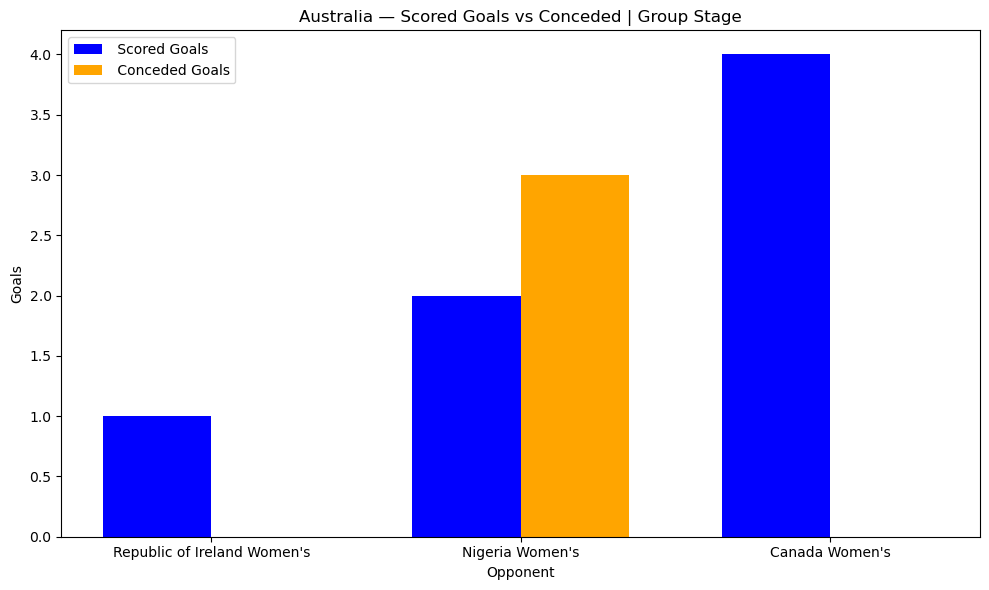

In [11]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Australia Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Australia — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

According to the chart above, Australia lost one game to Nigeria and won the other two against Ireland and Canada.

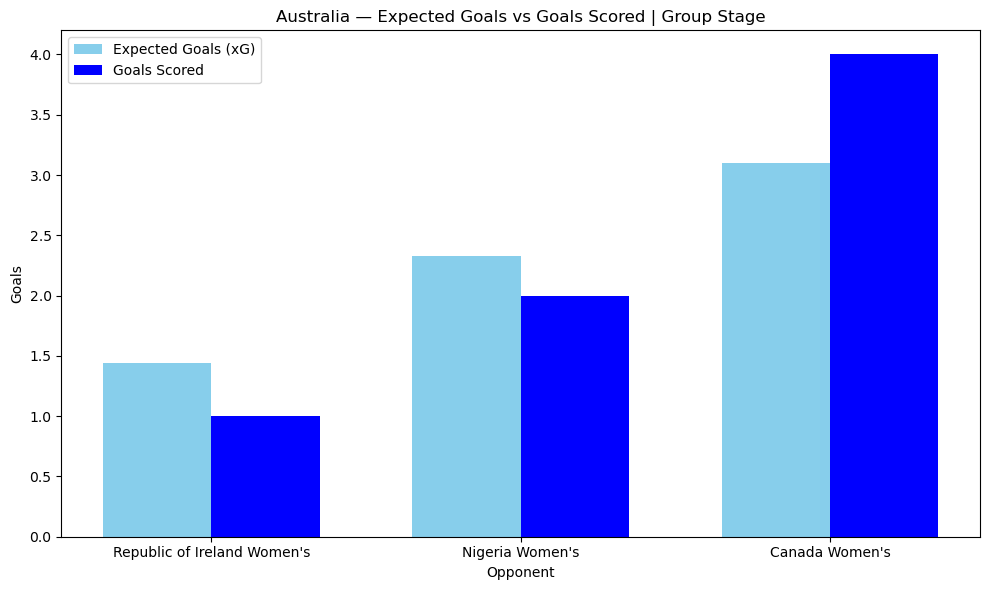

In [13]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Australia Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Australia — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

The graph shows the goals the team was expected to score versus the goals it actually scored. 
Here, Australia fell short of expectations in its first two games (IRL and NGA) and exceeded them in the game against Canada. 
Let’s look at the graphs for each game.

# Analysis of AUS-IRL

In [16]:
# Select the Australia vs Ireland match

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "Republic of Ireland Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Republic of Ireland Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Australia": [
        match.loc[
            match["team"] == "Australia Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Ireland": [
        match.loc[
            match["team"] == "Republic of Ireland Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "Ireland"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "Ireland"]
].round(1)


# Display table

comparison

,Metric,Australia,Ireland
0,Goals,1.0,0.0
1,xG,1.4,0.7
2,Goals Minus xG,-0.4,-0.7
3,Shots,13.0,9.0
4,Shots on Target,2.0,1.0
5,Saves,1.0,1.0
6,Possession %,58.0,42.0
7,Pass Accuracy %,80.9,62.2
8,Progressive Passes,134.0,87.0
9,Progressive Carries,31.0,16.0


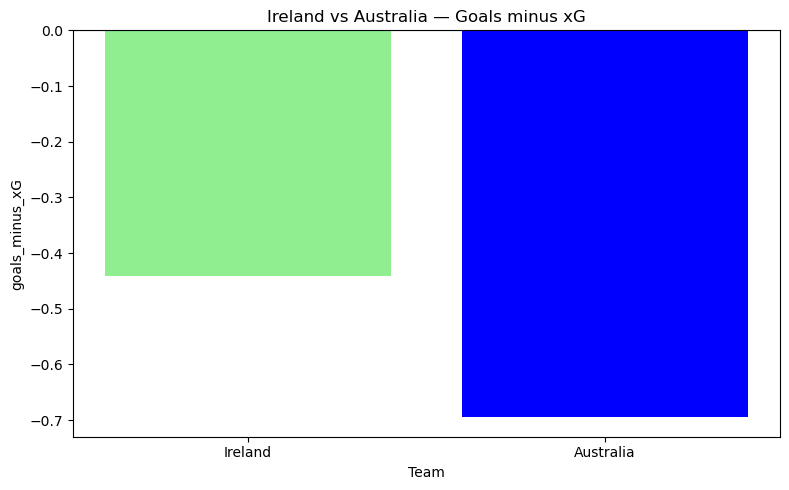

In [17]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "Republic of Ireland Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Republic of Ireland Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
].copy()


teams = ["Ireland", "Australia"]

goals_minus_xG = [
    match.loc[match["team"] == "Australia Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Republic of Ireland Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["lightgreen", "blue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Ireland vs Australia — Goals minus xG")

plt.tight_layout()
plt.show()

Although Australia won the match by one goal, both teams were bellow of what was expected of them. 

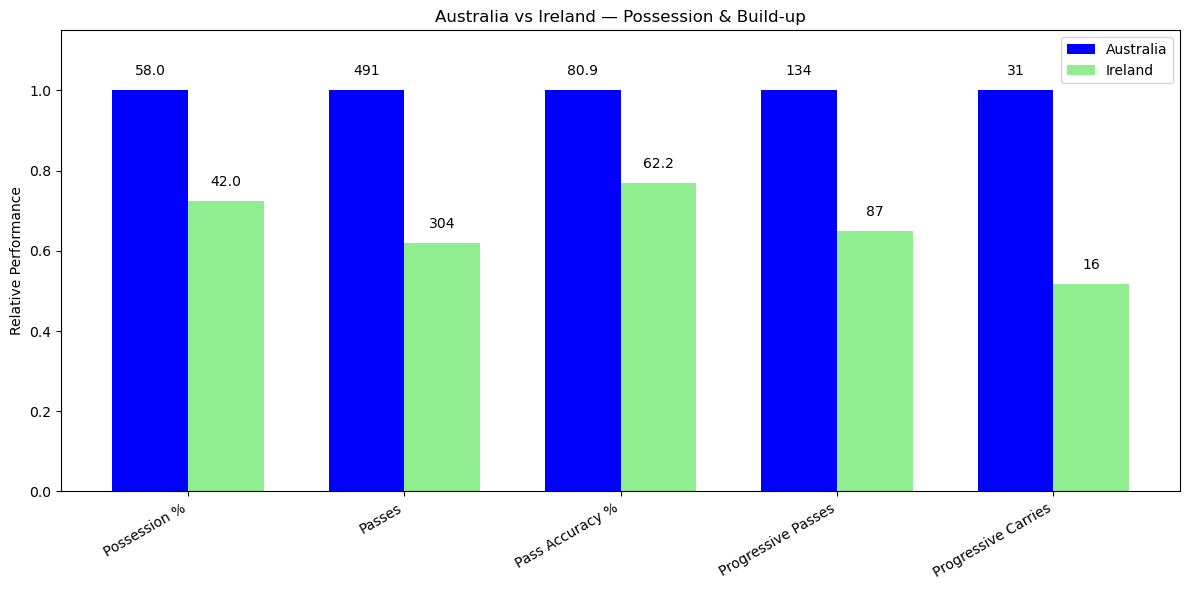

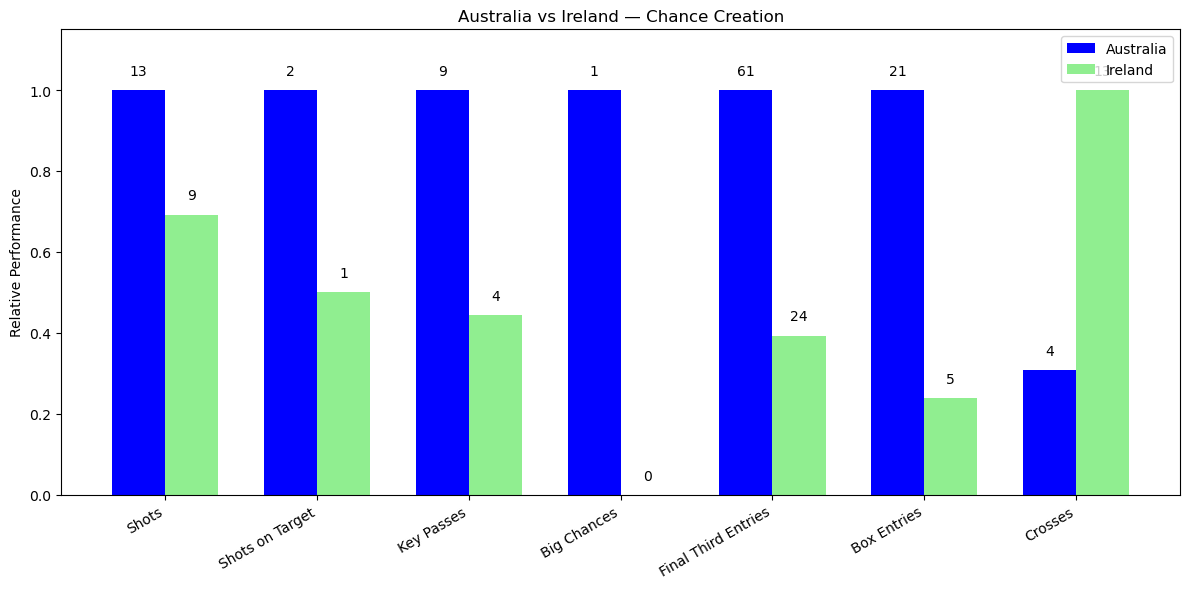

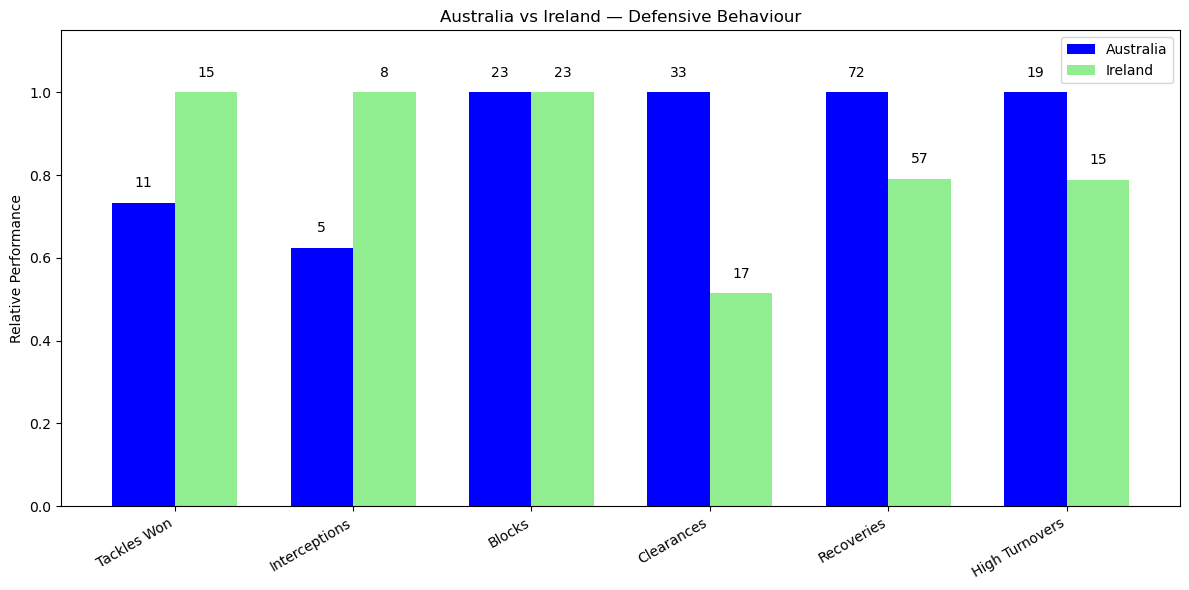

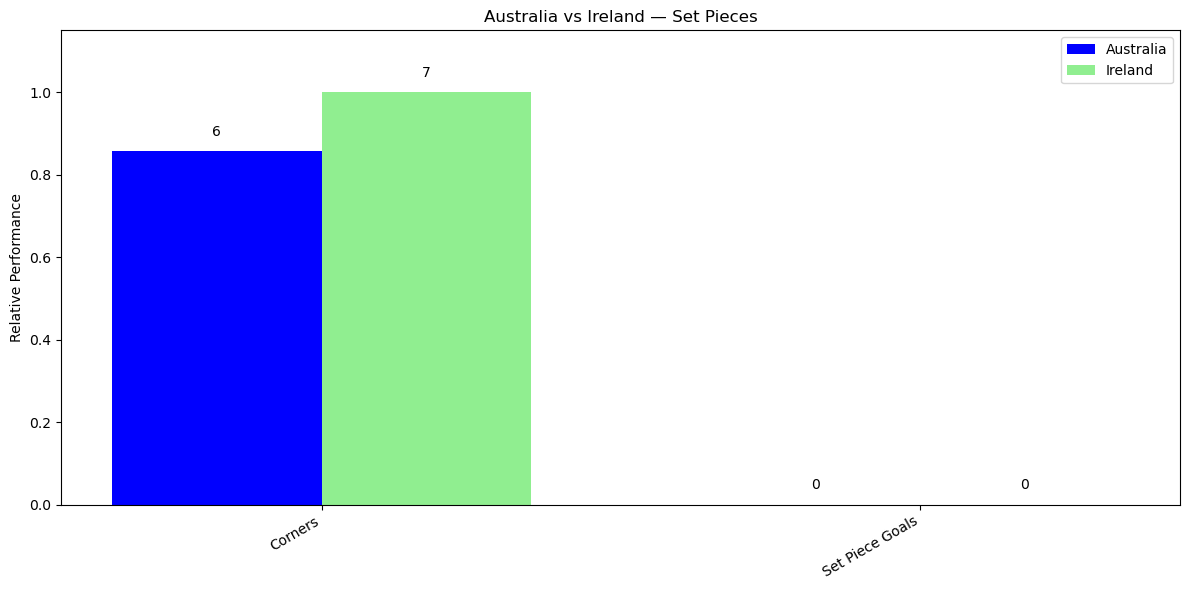

In [19]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "Republic of Ireland Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Republic of Ireland Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Australia": "Australia Women's",
    "Ireland": "Republic of Ireland Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    aus_values = np.array([
        match.loc[
            match["team"] == team_names["Australia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    irl_values = np.array([
        match.loc[
            match["team"] == team_names["Ireland"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(aus_values, irl_values)

    # Normalize
    aus_normalized = np.divide(
        aus_values,
        max_values,
        out=np.zeros_like(aus_values),
        where=max_values != 0
    )

    irl_normalized = np.divide(
        irl_values,
        max_values,
        out=np.zeros_like(irl_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_aus = plt.bar(
        x - width / 2,
        aus_normalized,
        width,
        label="Australia",
        color="blue"
    )

    bars_irl = plt.bar(
        x + width / 2,
        irl_normalized,
        width,
        label="Ireland",
        color="lightgreen"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_aus, aus_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_irl, irl_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Australia vs Ireland — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion AUS-IRL

Australia dominated the field in the match against Ireland. The difference in the numbers is striking in the *Possession & Build-up* and *Chance Creation* charts. 

In the *Defense Behavior* chart, however, Ireland shows higher numbers; nevertheless, it is presumed that these were in response to Australia’s constant attack. 

# Analysis of AUS-NGA

In [23]:

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "Nigeria Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Nigeria Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Australia": [
        match.loc[
            match["team"] == "Australia Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Nigeria": [
        match.loc[
            match["team"] == "Nigeria Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "Nigeria"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "Nigeria"]
].round(1)


# Display table

comparison

,Metric,Australia,Nigeria
0,Goals,2.0,3.0
1,xG,2.3,1.2
2,Goals Minus xG,-0.3,1.8
3,Shots,29.0,11.0
4,Shots on Target,8.0,6.0
5,Saves,3.0,6.0
6,Possession %,66.0,34.0
7,Pass Accuracy %,75.5,61.3
8,Progressive Passes,119.0,83.0
9,Progressive Carries,22.0,15.0


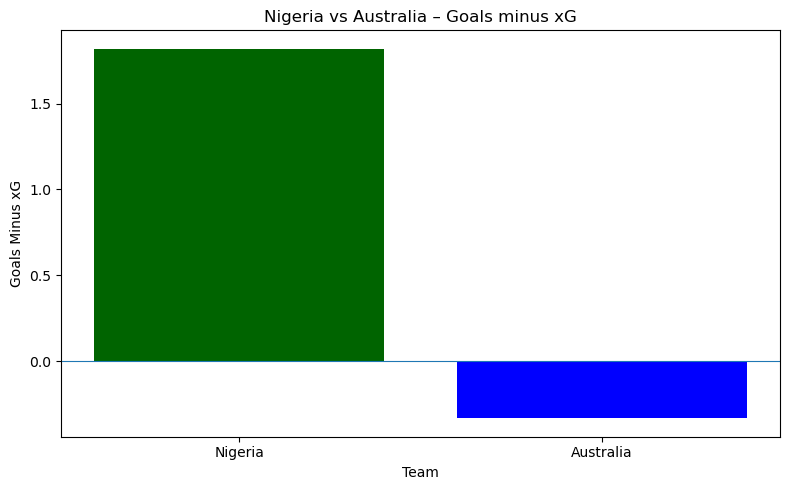

In [24]:
teams = ["Nigeria", "Australia"]

goals_minus_xG = [
    match.loc[match["team"] == "Nigeria Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Australia Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["darkgreen", "blue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("Goals Minus xG")
plt.title("Nigeria vs Australia – Goals minus xG")

plt.tight_layout()
plt.show()

In its match against Australia, Nigeria exceeded expectations by scoring more goals than anticipated. Australia, on the other hand, did the opposite. Even though both teams scored, Nigeria won by one goal.

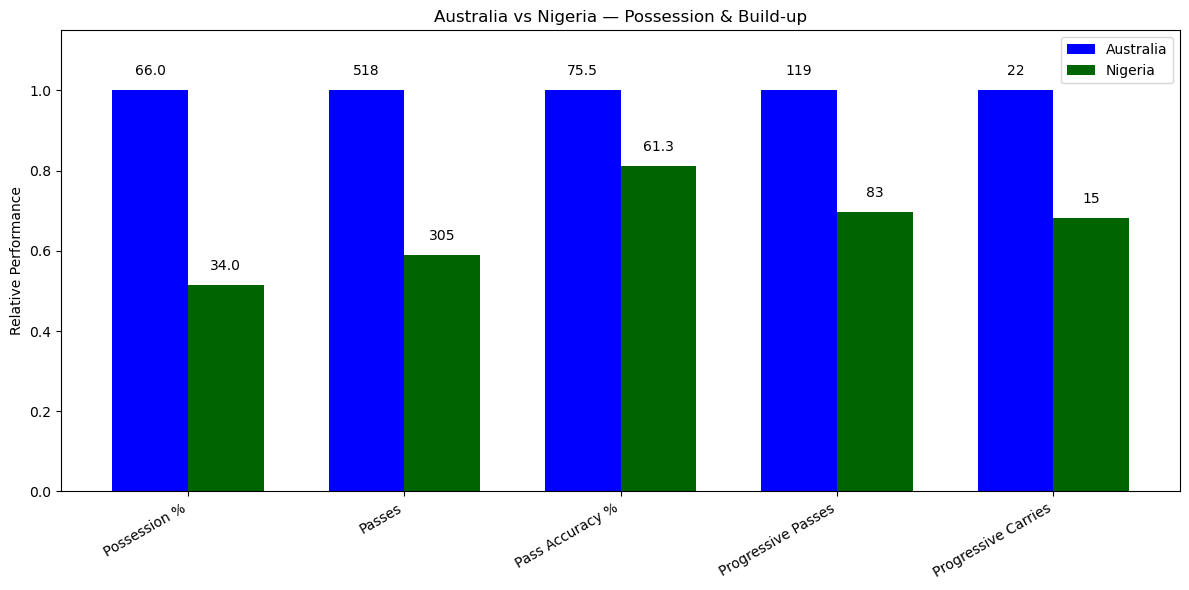

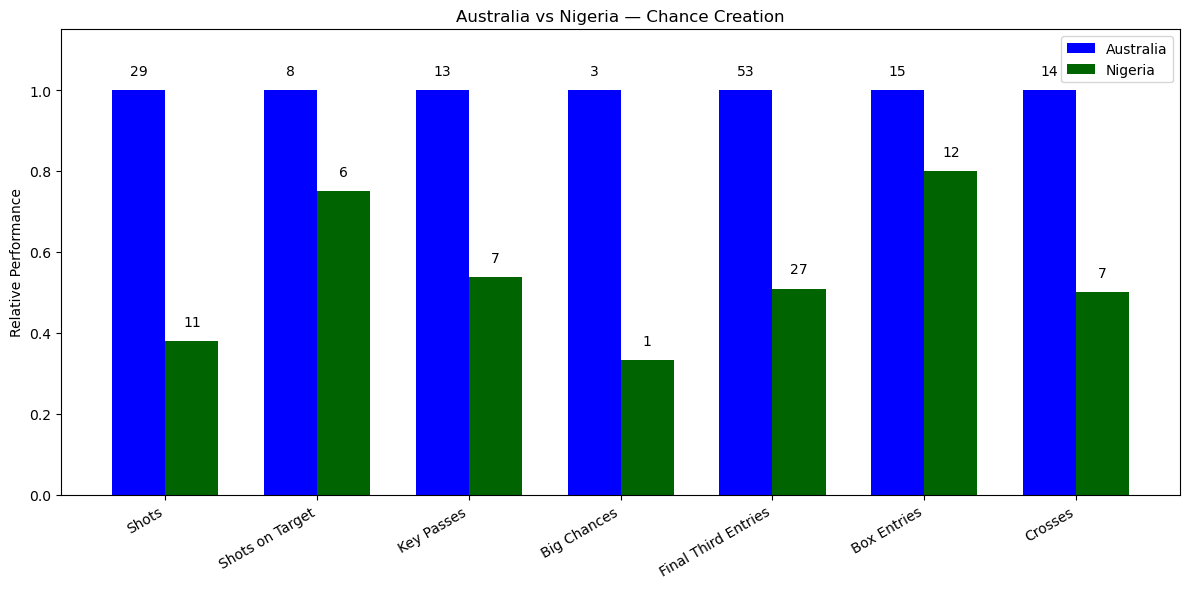

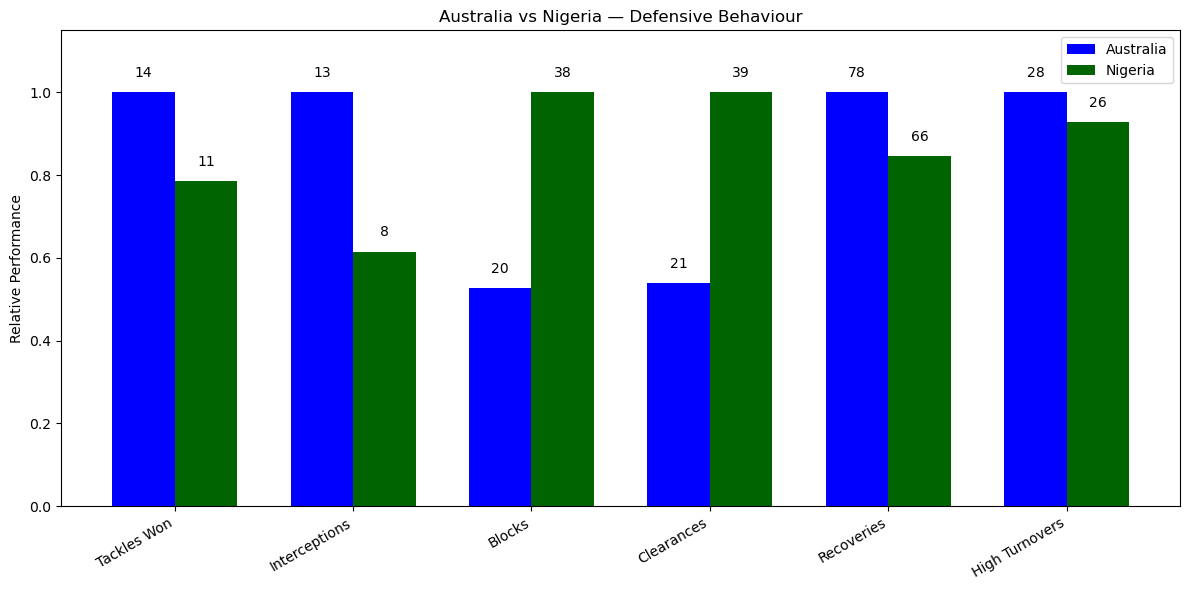

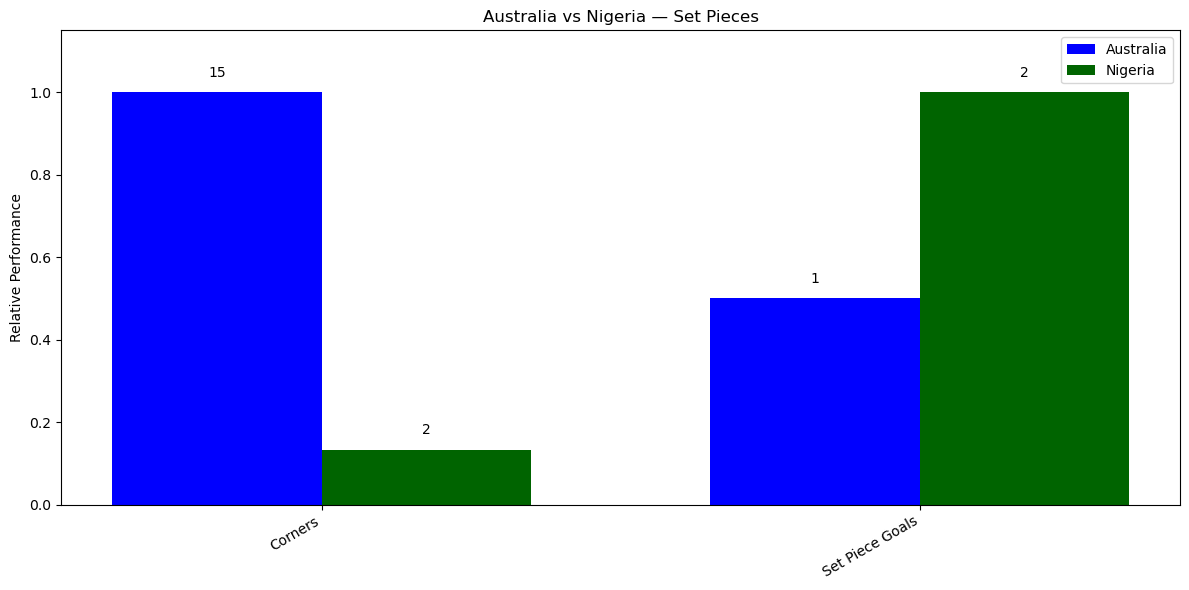

In [26]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "Nigeria Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Nigeria Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Australia": "Australia Women's",
    "Nigeria": "Nigeria Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    aus_values = np.array([
        match.loc[
            match["team"] == team_names["Australia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    nga_values = np.array([
        match.loc[
            match["team"] == team_names["Nigeria"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(aus_values, nga_values)

    # Normalize
    aus_normalized = np.divide(
        aus_values,
        max_values,
        out=np.zeros_like(aus_values),
        where=max_values != 0
    )

    nga_normalized = np.divide(
        nga_values,
        max_values,
        out=np.zeros_like(nga_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_aus = plt.bar(
        x - width / 2,
        aus_normalized,
        width,
        label="Australia",
        color="blue"
    )

    bars_nga = plt.bar(
        x + width / 2,
        nga_normalized,
        width,
        label="Nigeria",
        color="darkgreen"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_aus, aus_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_nga, nga_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Australia vs Nigeria — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of AUS-NGA

Australia showed greater attacking involvement overall, creating more attacking actions and displaying a **stronger presence in the final third**. However, Nigeria remained **highly competitive** across the different areas of the game, matching Australia in several **key metrics** and demonstrating a well-balanced performance.

The main difference came in finishing efficiency. Despite Australia's greater attacking output, Nigeria was more effective in converting its opportunities into goals. Nigeria therefore showed that a team does not necessarily need to dominate attacking volume to be more effective in front of goal. Overall, the match was relatively balanced in terms of performance, with Australia generating more attacking activity, while Nigeria proved more clinical and efficient in the decisive moments.

# Analysis of AUS-CAN

In [46]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "Canada Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Canada Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Australia": [
        match.loc[
            match["team"] == "Australia Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Canada": [
        match.loc[
            match["team"] == "Canada Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "Canada"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Australia", "Canada"]
].round(1)


# Display table

comparison

,Metric,Australia,Canada
0,Goals,4.0,0.0
1,xG,3.1,0.5
2,Goals Minus xG,0.9,-0.5
3,Shots,11.0,11.0
4,Shots on Target,6.0,3.0
5,Saves,3.0,3.0
6,Possession %,40.9,59.1
7,Pass Accuracy %,62.2,74.4
8,Progressive Passes,109.0,147.0
9,Progressive Carries,12.0,24.0


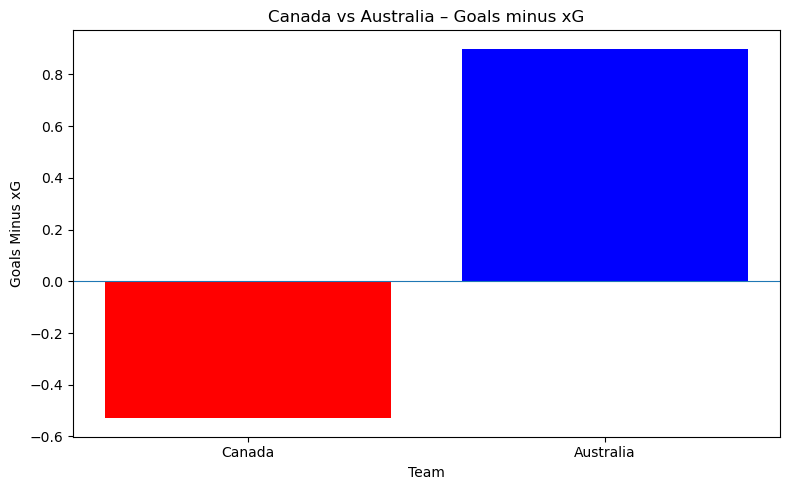

In [48]:
teams = ["Canada", "Australia"]

goals_minus_xG = [
    match.loc[match["team"] == "Canada Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Australia Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["red", "blue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("Goals Minus xG")
plt.title("Canada vs Australia – Goals minus xG")

plt.tight_layout()
plt.show()

Australia was above the expectations of goals, with 4 goals scorred and a xG 3,1. Canada was bellow the expectations with 0 scored goals and 0,5 xG.

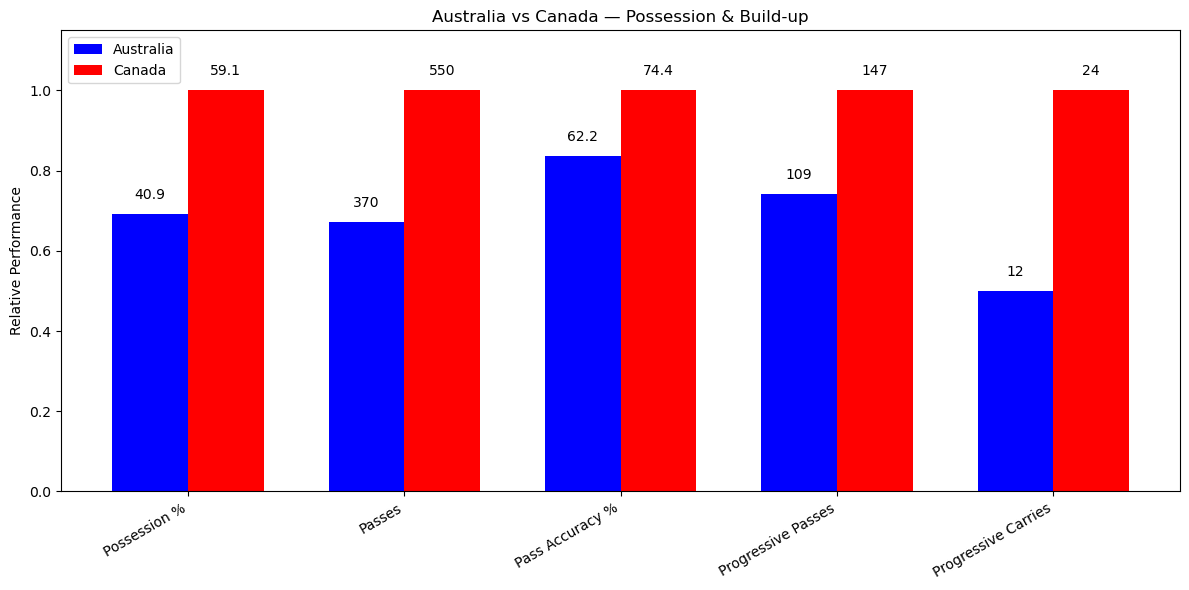

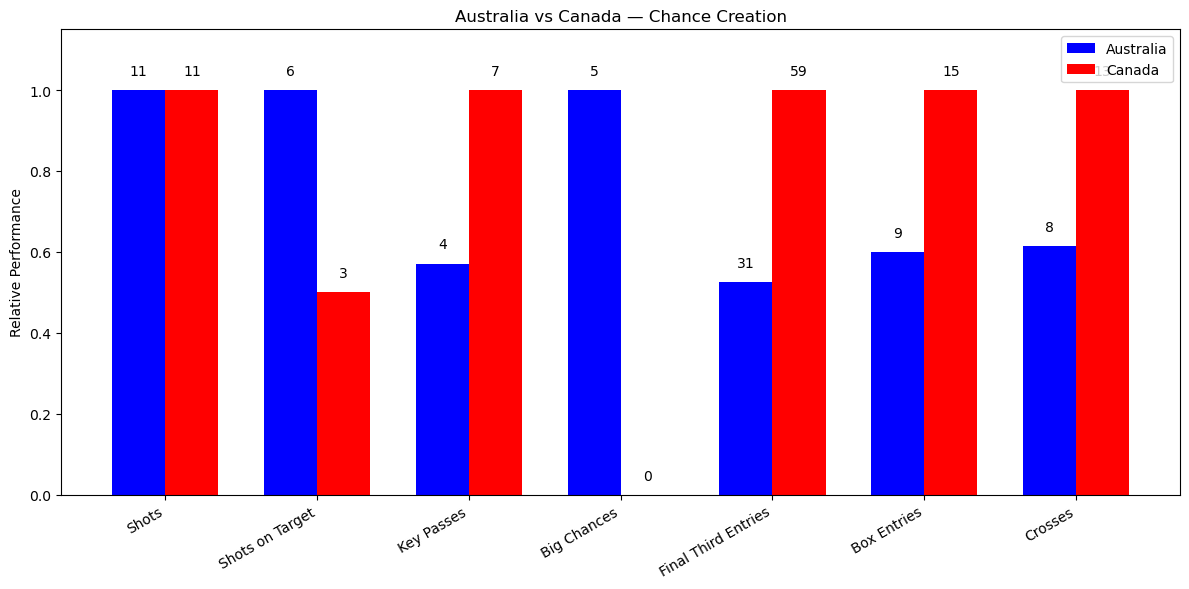

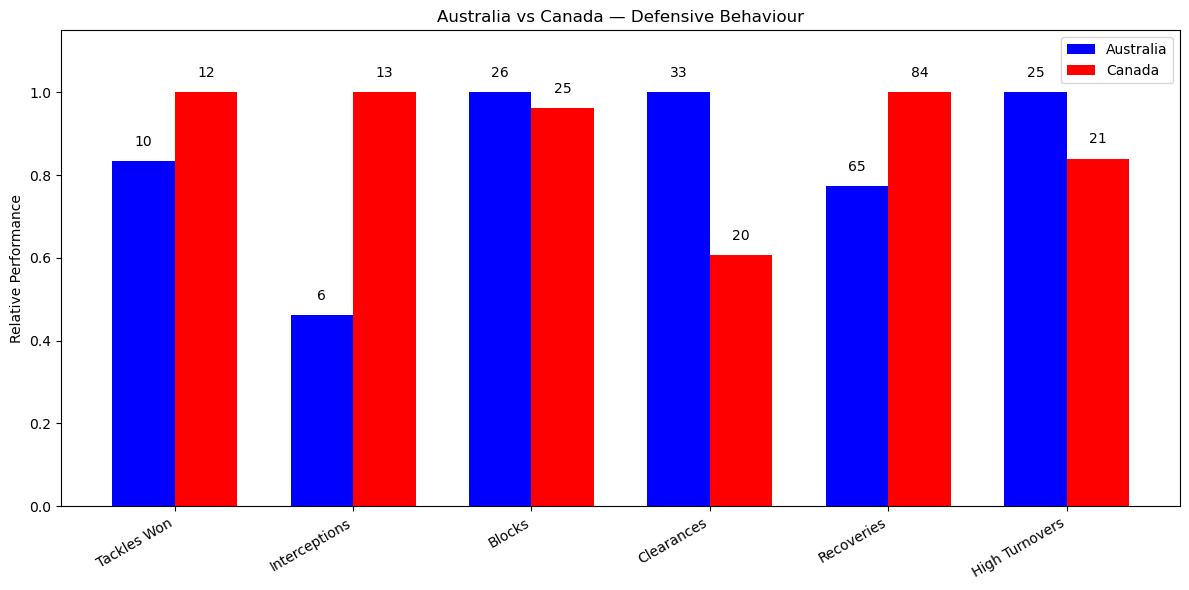

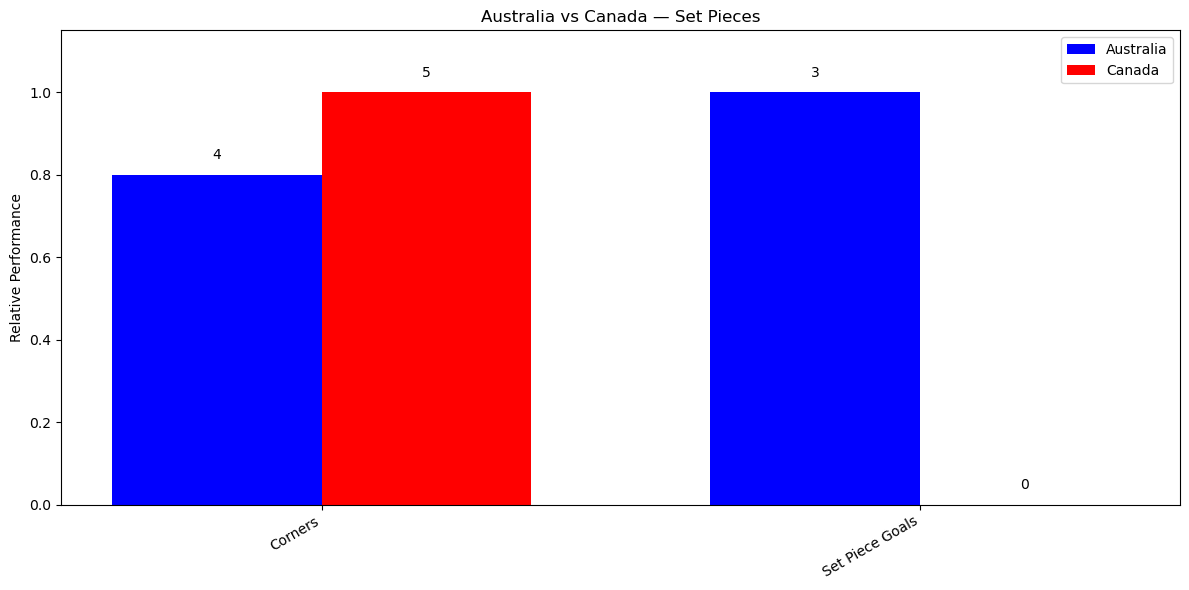

In [50]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Australia Women's") &
        (womens_world_cup_stats["opponent"] == "Canada Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Canada Women's") &
        (womens_world_cup_stats["opponent"] == "Australia Women's")
    )
].copy()

# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Australia": "Australia Women's",
    "Canada": "Canada Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    aus_values = np.array([
        match.loc[
            match["team"] == team_names["Australia"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    can_values = np.array([
        match.loc[
            match["team"] == team_names["Canada"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(aus_values, can_values)

    # Normalize
    aus_normalized = np.divide(
        aus_values,
        max_values,
        out=np.zeros_like(aus_values),
        where=max_values != 0
    )

    can_normalized = np.divide(
        can_values,
        max_values,
        out=np.zeros_like(can_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_aus = plt.bar(
        x - width / 2,
        aus_normalized,
        width,
        label="Australia",
        color="blue"
    )

    bars_can = plt.bar(
        x + width / 2,
        can_normalized,
        width,
        label="Canada",
        color="red"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_aus, aus_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_can, can_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Australia vs Canada — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of AUS-CAN

Although Canada dominated possession, passing and progression, Australia was far more effective at creating high-quality chances. With only 40.9% possession, Australia produced 3.1 xG, compared to just 0.5 xG for Canada, and scored four goals.

This match shows that dominating possession does not necessarily mean creating more danger. Canada had more volume, but Australia was much more efficient in turning its opportunities into genuine scoring chances — a difference that was ultimately reflected in the 4–0 final score.

# Analysis Nigeria's Group Stage games

In [56]:
team = "Nigeria Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
6,3893790,Canada Women's,Nigeria Women's,Group
7,3893790,Nigeria Women's,Canada Women's,Group
44,3893809,Australia Women's,Nigeria Women's,Group
45,3893809,Nigeria Women's,Australia Women's,Group
74,3893824,Nigeria Women's,Republic of Ireland Women's,Group
75,3893824,Republic of Ireland Women's,Nigeria Women's,Group


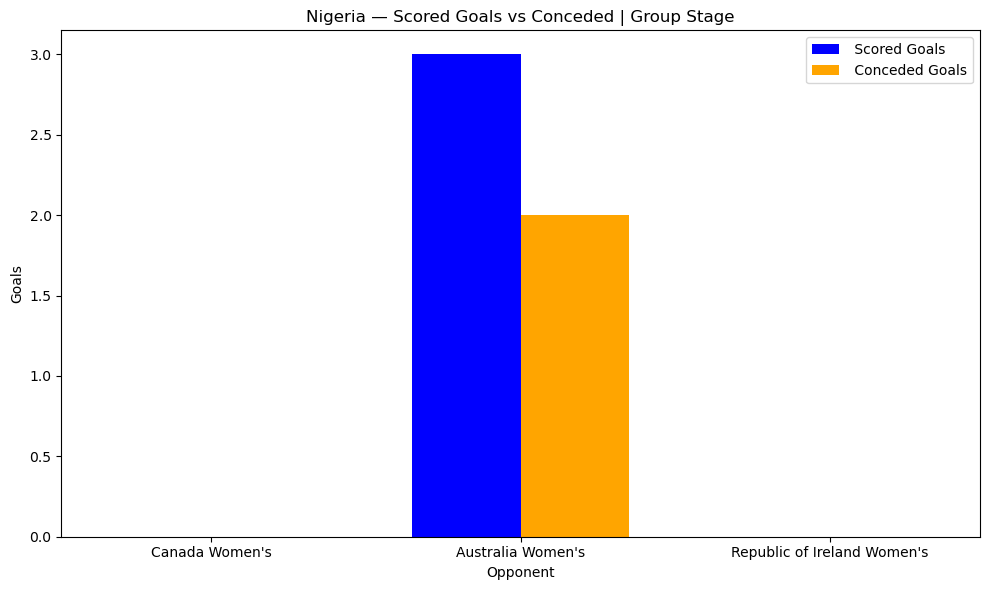

In [58]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Nigeria Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Nigeria — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

According to the chart above, Nigeria did not score any goals against Canada or Ireland and did not concede any goals to those opponents. However, in the match against Australia, it conceded two goals and scored three.

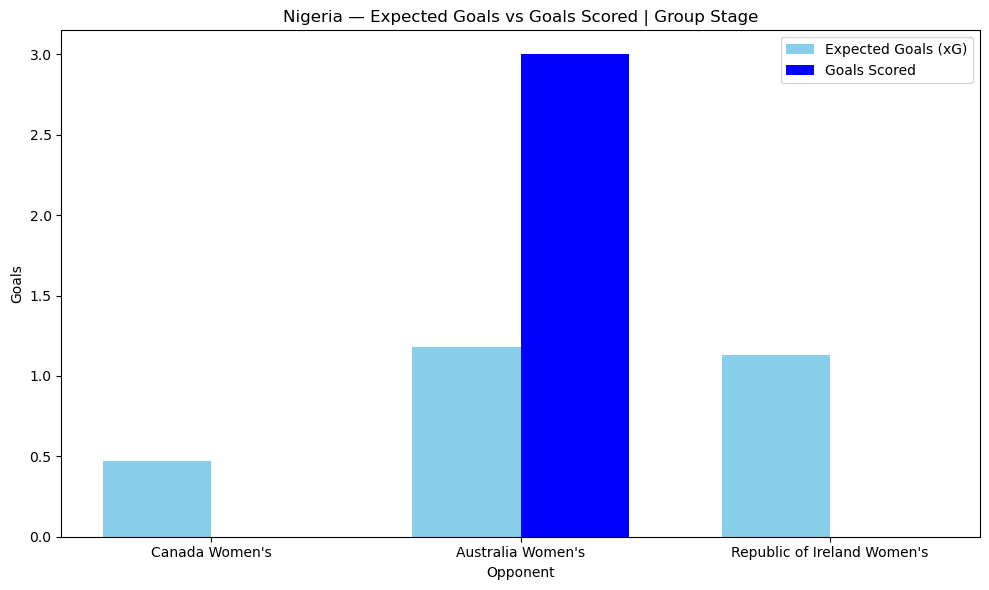

In [60]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Nigeria Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Nigeria — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Nigeria consistently fell short of expectations, failing to score against Ireland and Canada, but surpassed itself by scoring more goals in the game against Australia. Let's analyse de CAN and IRL games. 

# Analysis of NGA-CAN

In [70]:
match = womens_world_cup_stats[
    ( 
        (womens_world_cup_stats["team"] == "Canada Women's") &
        (womens_world_cup_stats["opponent"] == "Nigeria Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Nigeria Women's") &
        (womens_world_cup_stats["opponent"] == "Canada Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Canada": [
        match.loc[
            match["team"] == "Canada Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Nigeria": [
        match.loc[
            match["team"] == "Nigeria Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Canada", "Nigeria"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Canada", "Nigeria"]
].round(1)


# Display table

comparison

,Metric,Canada,Nigeria
0,Goals,0.0,0.0
1,xG,1.6,0.5
2,Goals Minus xG,-1.6,-0.5
3,Shots,16.0,10.0
4,Shots on Target,3.0,1.0
5,Saves,1.0,4.0
6,Possession %,65.7,34.3
7,Pass Accuracy %,79.1,57.3
8,Progressive Passes,126.0,73.0
9,Progressive Carries,18.0,14.0


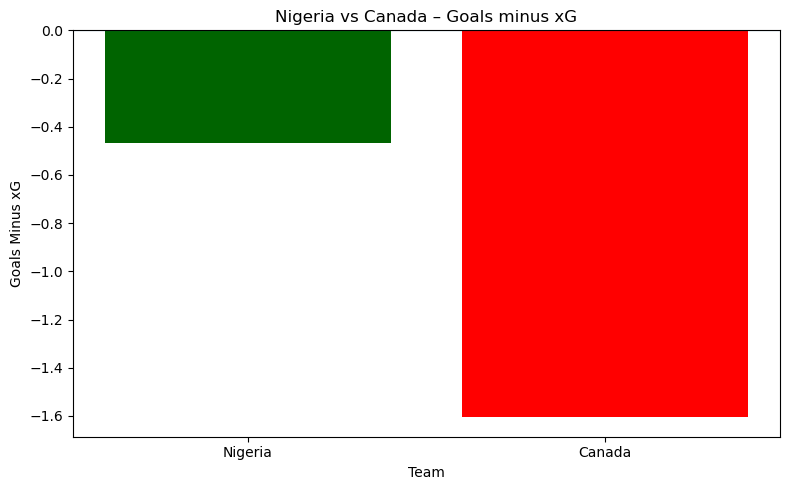

In [72]:
teams = ["Nigeria", "Canada"]

goals_minus_xG = [
    match.loc[match["team"] == "Nigeria Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Canada Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["darkgreen", "red"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("Goals Minus xG")
plt.title("Nigeria vs Canada – Goals minus xG")

plt.tight_layout()
plt.show()

Both teams fell short of expectations, especially Canada, which had an xG of 1.6 but failed to score a single goal.

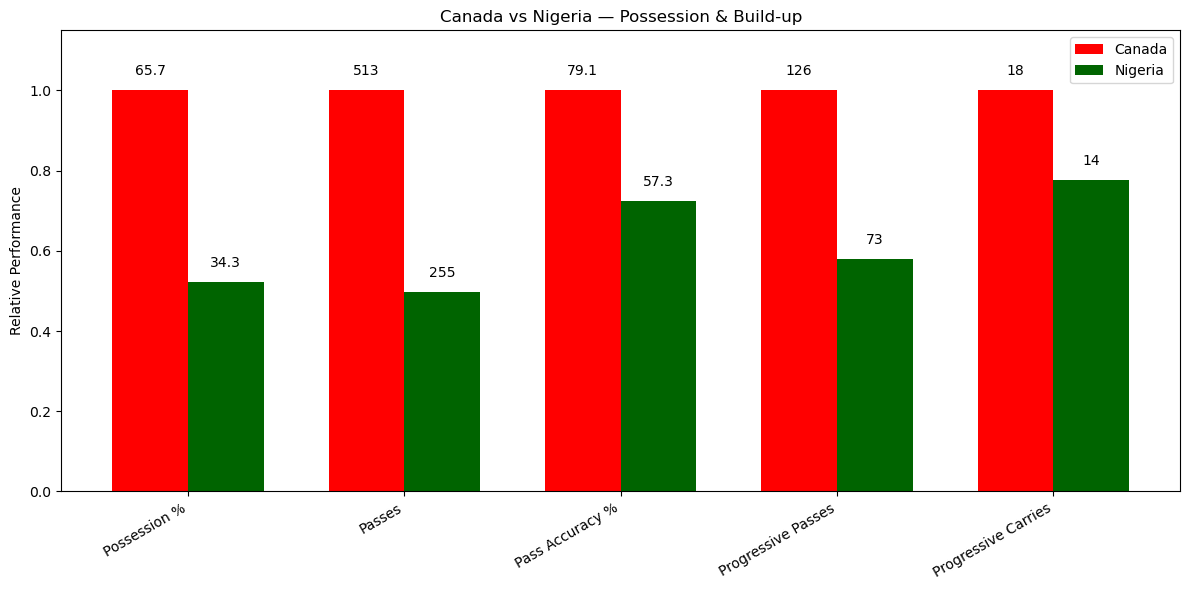

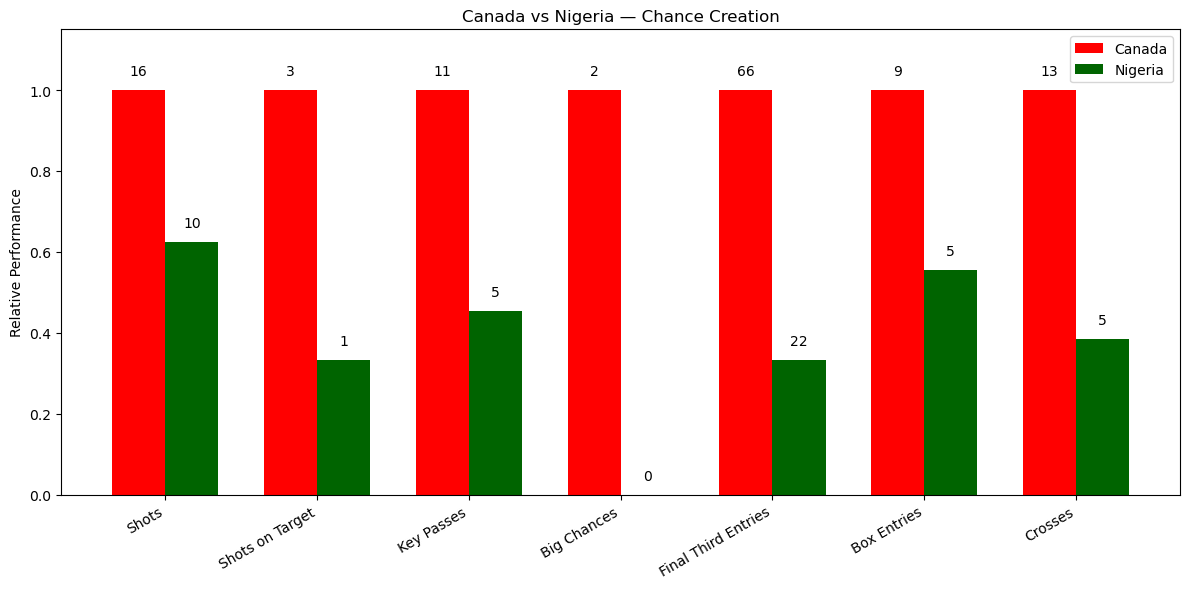

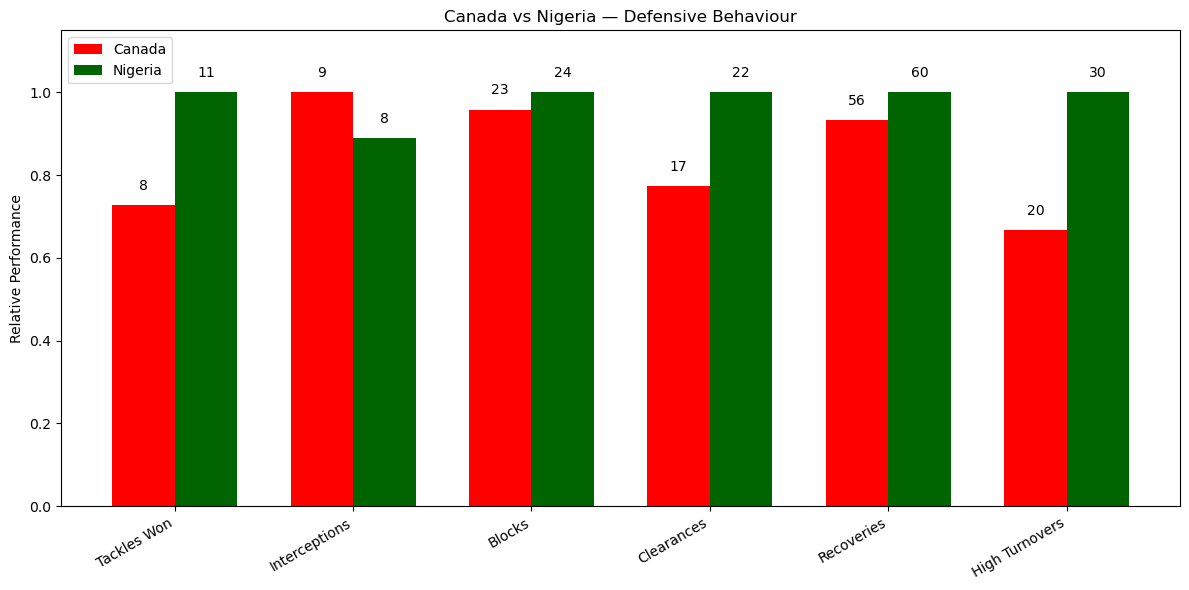

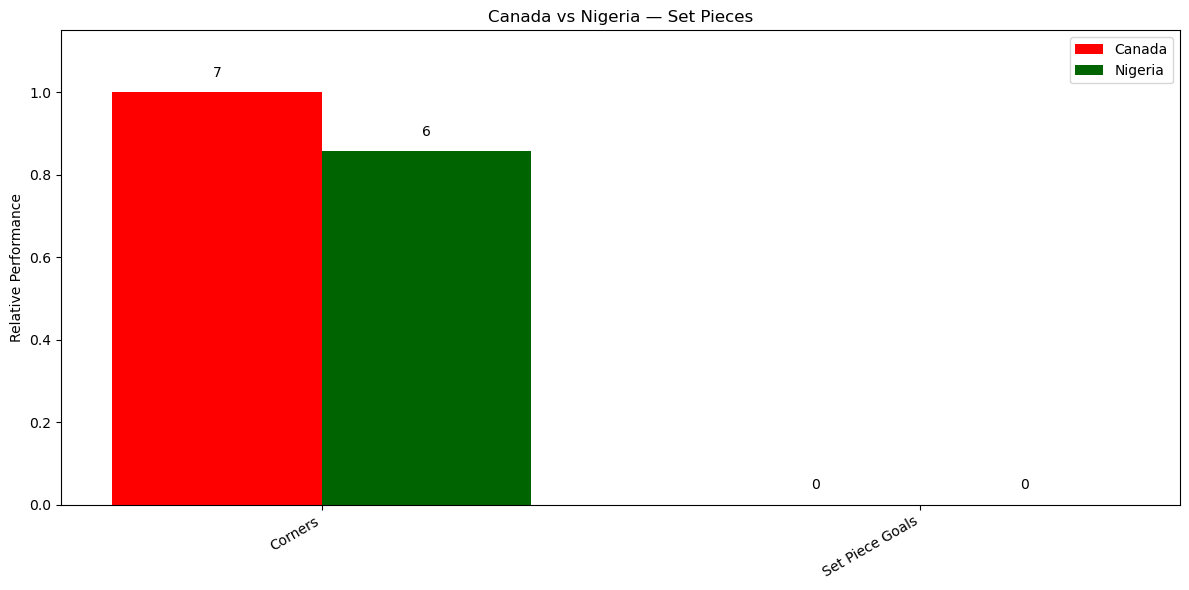

In [75]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    ( 
        (womens_world_cup_stats["team"] == "Canada Women's") &
        (womens_world_cup_stats["opponent"] == "Nigeria Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Nigeria Women's") &
        (womens_world_cup_stats["opponent"] == "Canada Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Canada": "Canada Women's",
    "Nigeria": "Nigeria Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    can_values = np.array([
        match.loc[
            match["team"] == team_names["Canada"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    nga_values = np.array([
        match.loc[
            match["team"] == team_names["Nigeria"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(can_values, nga_values)

    # Normalize
    can_normalized = np.divide(
        can_values,
        max_values,
        out=np.zeros_like(can_values),
        where=max_values != 0
    )

    nga_normalized = np.divide(
        nga_values,
        max_values,
        out=np.zeros_like(nga_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_can = plt.bar(
        x - width / 2,
        can_normalized,
        width,
        label="Canada",
        color="red"
    )

    bars_nga = plt.bar(
        x + width / 2,
        nga_normalized,
        width,
        label="Nigeria",
        color="darkgreen"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_can, can_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_nga, nga_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Canada vs Nigeria — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of NGA-CAN

The game shown above was a very evenly matched contest in which there could have been quite a few positive outcomes. 
Canada played more offensively during the game, but Nigeria defended strongly, as can be seen in the *Defensive Behavior* chart.
I can conclude that it was a game that went quite against the grain for the Canadian team, but it showed how Nigeria reacts to teams that play very aggressively.

# Analysis of NGA-IRL

In [82]:
match = womens_world_cup_stats[
    ( 
        (womens_world_cup_stats["team"] == "Republic of Ireland Women's") &
        (womens_world_cup_stats["opponent"] == "Nigeria Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Nigeria Women's") &
        (womens_world_cup_stats["opponent"] == "Republic of Ireland Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Ireland": [
        match.loc[
            match["team"] == "Republic of Ireland Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Nigeria": [
        match.loc[
            match["team"] == "Nigeria Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Ireland", "Nigeria"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Ireland", "Nigeria"]
].round(1)


# Display table

comparison

,Metric,Ireland,Nigeria
0,Goals,0.0,0.0
1,xG,0.5,1.1
2,Goals Minus xG,-0.5,-1.1
3,Shots,5.0,11.0
4,Shots on Target,1.0,1.0
5,Saves,2.0,1.0
6,Possession %,52.5,47.5
7,Pass Accuracy %,82.4,81.0
8,Progressive Passes,128.0,93.0
9,Progressive Carries,27.0,23.0


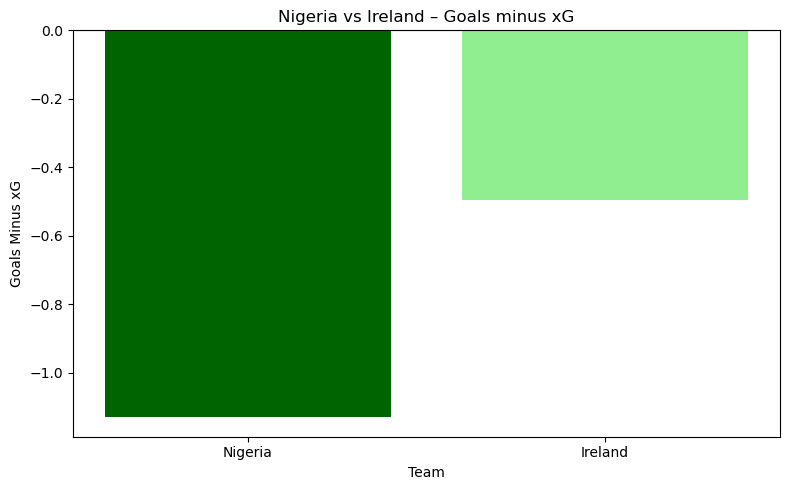

In [84]:
teams = ["Nigeria", "Ireland"]

goals_minus_xG = [
    match.loc[match["team"] == "Nigeria Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Republic of Ireland Women's", "goals_minus_xG"].iloc[0]
]

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["darkgreen", "lightgreen"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("Goals Minus xG")
plt.title("Nigeria vs Ireland – Goals minus xG")

plt.tight_layout()
plt.show()

This chart shows that neither team managed to meet or exceed expectations, with Nigeria showing a greater discrepancy.<br>
- 1.1 xG but scored 0 goals, so xG minus goals = -1.1

Let's take a look at the game statistics for better understanding.

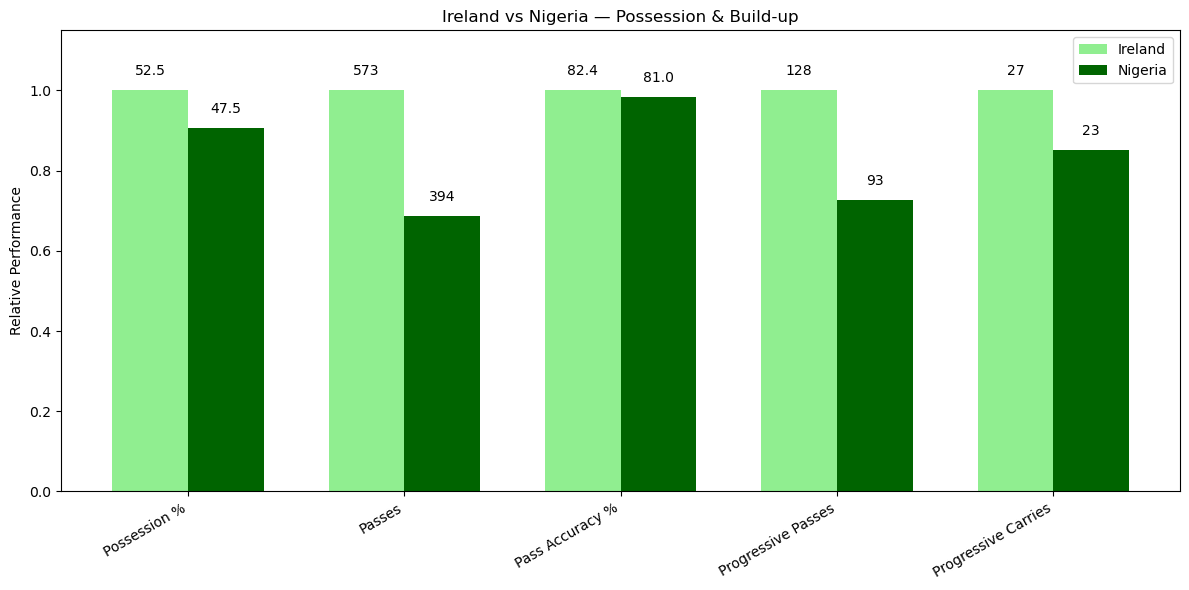

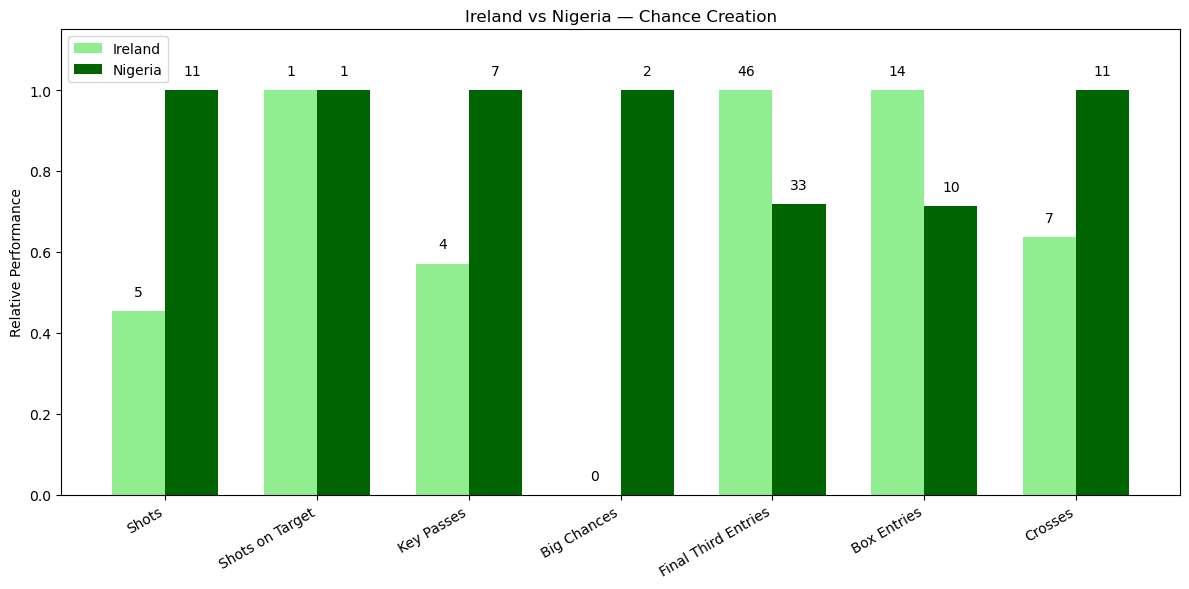

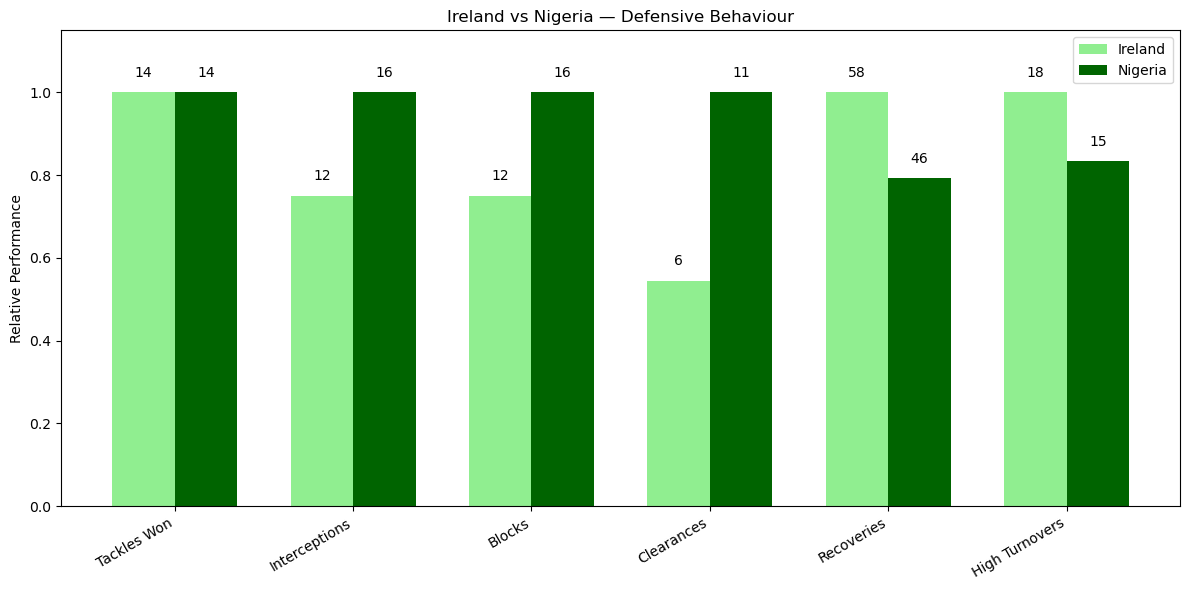

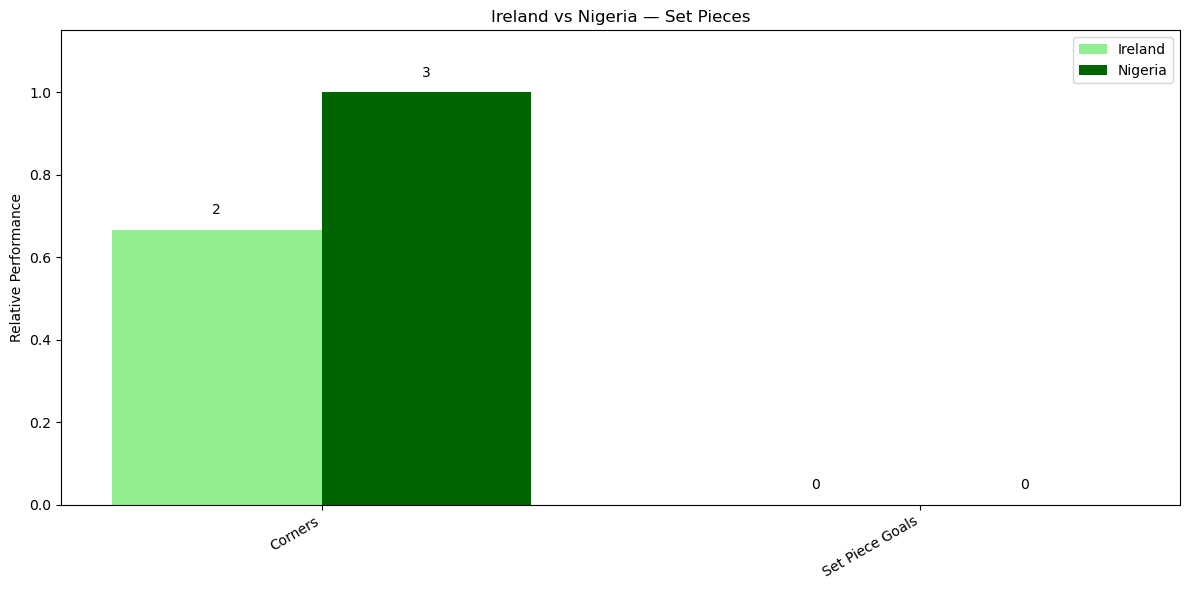

In [92]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    ( 
        (womens_world_cup_stats["team"] == "Republic of Ireland Women's") &
        (womens_world_cup_stats["opponent"] == "Nigeria Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Nigeria Women's") &
        (womens_world_cup_stats["opponent"] == "Republic of Ireland Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Ireland": "Republic of Ireland Women's",
    "Nigeria": "Nigeria Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    irl_values = np.array([
        match.loc[
            match["team"] == team_names["Ireland"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    nga_values = np.array([
        match.loc[
            match["team"] == team_names["Nigeria"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(irl_values, nga_values)

    # Normalize
    irl_normalized = np.divide(
        irl_values,
        max_values,
        out=np.zeros_like(irl_values),
        where=max_values != 0
    )

    nga_normalized = np.divide(
        nga_values,
        max_values,
        out=np.zeros_like(nga_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_irl = plt.bar(
        x - width / 2,
        irl_normalized,
        width,
        label="Ireland",
        color="lightgreen"
    )

    bars_nga = plt.bar(
        x + width / 2,
        nga_normalized,
        width,
        label="Nigeria",
        color="darkgreen"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_irl, irl_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_nga, nga_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Ireland vs Nigeria — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of NGA - IRL

Ireland controlled more of the possession and build-up, while Nigeria created the more dangerous opportunities. Nigeria recorded 1.1 xG compared to Ireland’s 0.5 xG, suggesting that their chances were generally of higher quality.

However, neither team managed to convert that advantage into goals, with the match ending 0–0. Ultimately, Nigeria looked more threatening in attack, while Ireland had greater control of the ball — but both teams lacked the finishing efficiency needed to turn their chances into a decisive result.

# Analysis Canada's Group Stage games

In [97]:
team = "Canada Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
6,3893790,Canada Women's,Nigeria Women's,Group
7,3893790,Nigeria Women's,Canada Women's,Group
40,3893807,Canada Women's,Republic of Ireland Women's,Group
41,3893807,Republic of Ireland Women's,Canada Women's,Group
68,3893821,Australia Women's,Canada Women's,Group
69,3893821,Canada Women's,Australia Women's,Group


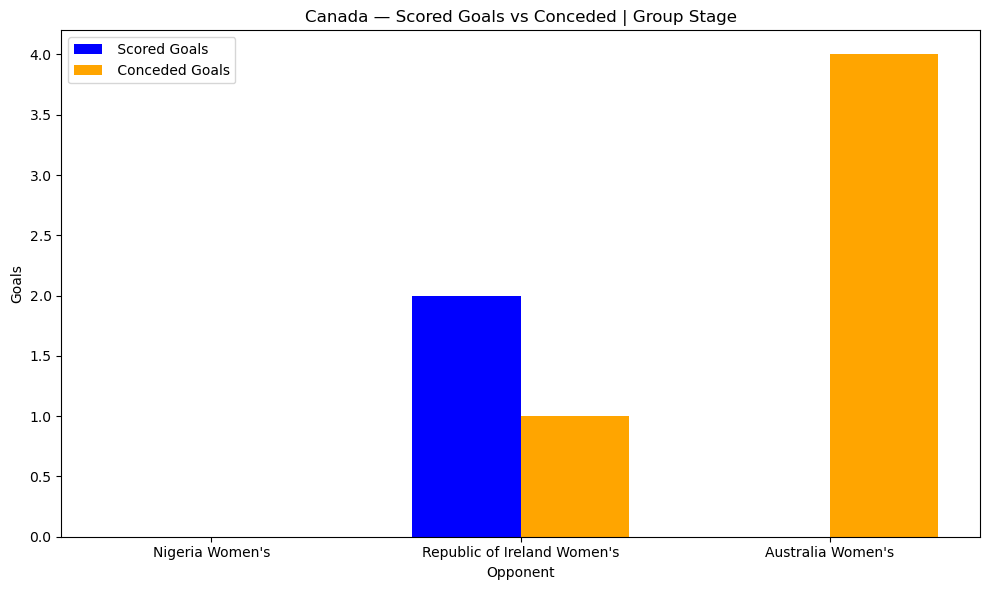

In [99]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Canada Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Canada — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

According to the chart above, Canada won one game, scorring 2 goals, lost one game by 4 goals and tied one game. This shows a lack of consistency of the team. 

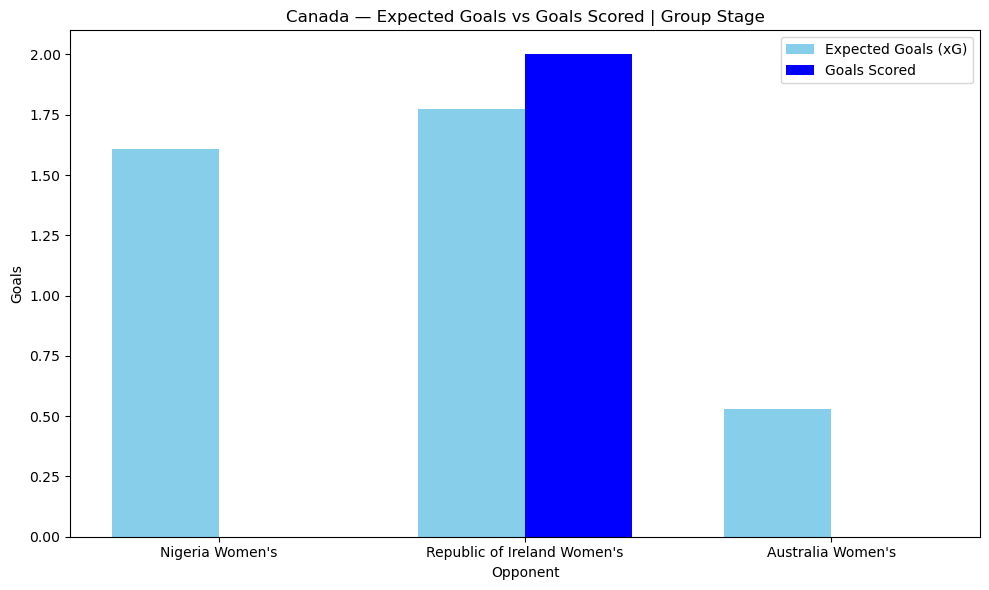

In [104]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Canada Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Canada — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Canada was always bellow of the expectations except in the match with Ireland. Let's take a look at the game.

### Correção de um erro no Dataset

In [116]:
# Recalculate Goals Minus xG
womens_world_cup_stats["goals_minus_xG"] = (
    womens_world_cup_stats["goals_for"] - womens_world_cup_stats["xG"]
)

In [112]:
match[[
    "team",
    "opponent",
    "goals_for",
    "xG",
    "goals_minus_xG"
]]

,team,opponent,goals_for,xG,goals_minus_xG
40,Canada Women's,Republic of Ireland Women's,2,1.771985,-0.771985
41,Republic of Ireland Women's,Canada Women's,1,1.023561,-0.023561


# Analysis of CAN-IRL

In [118]:
womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Canada Women's") &
        (womens_world_cup_stats["opponent"] == "Republic of Ireland Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Republic of Ireland Women's") &
        (womens_world_cup_stats["opponent"] == "Canada Women's")
    )
][[
    "team",
    "goals_for",
    "xG",
    "goals_minus_xG"
]]

,team,goals_for,xG,goals_minus_xG
40,Canada Women's,2,1.771985,0.228015
41,Republic of Ireland Women's,1,1.023561,-0.023561


In [122]:
match = womens_world_cup_stats[
    ( 
        (womens_world_cup_stats["team"] == "Republic of Ireland Women's") &
        (womens_world_cup_stats["opponent"] == "Canada Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Canada Women's") &
        (womens_world_cup_stats["opponent"] == "Republic of Ireland Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Ireland": [
        match.loc[
            match["team"] == "Republic of Ireland Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Canada": [
        match.loc[
            match["team"] == "Canada Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Ireland", "Canada"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Ireland", "Canada"]
].round(1)


# Display table

comparison

,Metric,Ireland,Canada
0,Goals,1.0,2.0
1,xG,1.0,1.8
2,Goals Minus xG,-0.0,0.2
3,Shots,14.0,17.0
4,Shots on Target,6.0,7.0
5,Saves,7.0,5.0
6,Possession %,42.2,57.8
7,Pass Accuracy %,61.9,77.2
8,Progressive Passes,101.0,145.0
9,Progressive Carries,9.0,31.0


In [147]:
# Get Goals Minus xG values
canada_value = match.loc[
    match["team"] == "Canada Women's",
    "goals_minus_xG"
].iloc[0]

ireland_value = match.loc[
    match["team"] == "Republic of Ireland Women's",
    "goals_minus_xG"
].iloc[0]

# Round to 1 decimal and force values very close to zero to exactly 0
canada_value = round(canada_value, 1)
ireland_value = round(ireland_value, 1)

if abs(ireland_value) < 0.05:
    ireland_value = 0.0

if abs(canada_value) < 0.05:
    canada_value = 0.0

values = [canada_value, ireland_value]

print(values)

[0.2, 0.0]


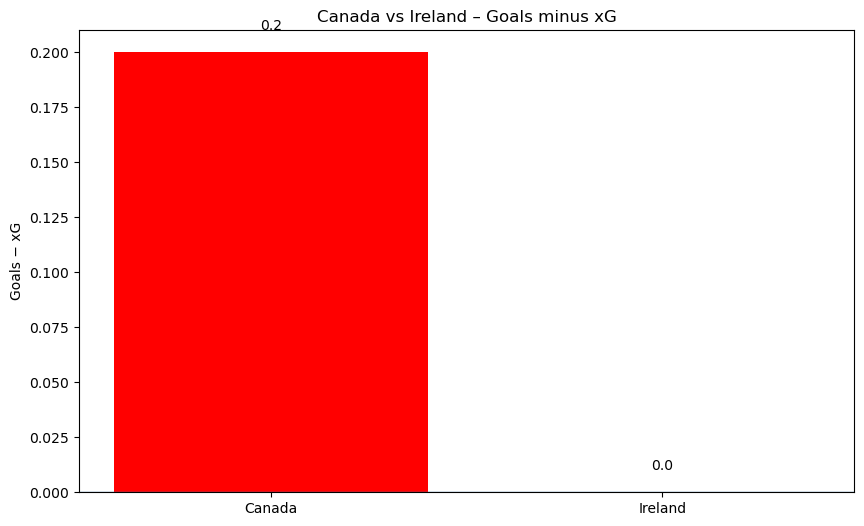

In [149]:
teams = ["Canada", "Ireland"]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    teams,
    values,
    color=["red", "lightgreen"]
)

plt.axhline(0, color="steelblue", linewidth=1)

plt.title("Canada vs Ireland – Goals minus xG")
plt.ylabel("Goals − xG")

# Labels
for bar, value in zip(bars, values):
    if value >= 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.01,
            f"{value:.1f}",
            ha="center"
        )
    else:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value - 0.02,
            f"{value:.1f}",
            ha="center"
        )

plt.show()

Both teams performed as expected. But it’s worth noting that Canada outperformed expectations, scoring more goals than expected.

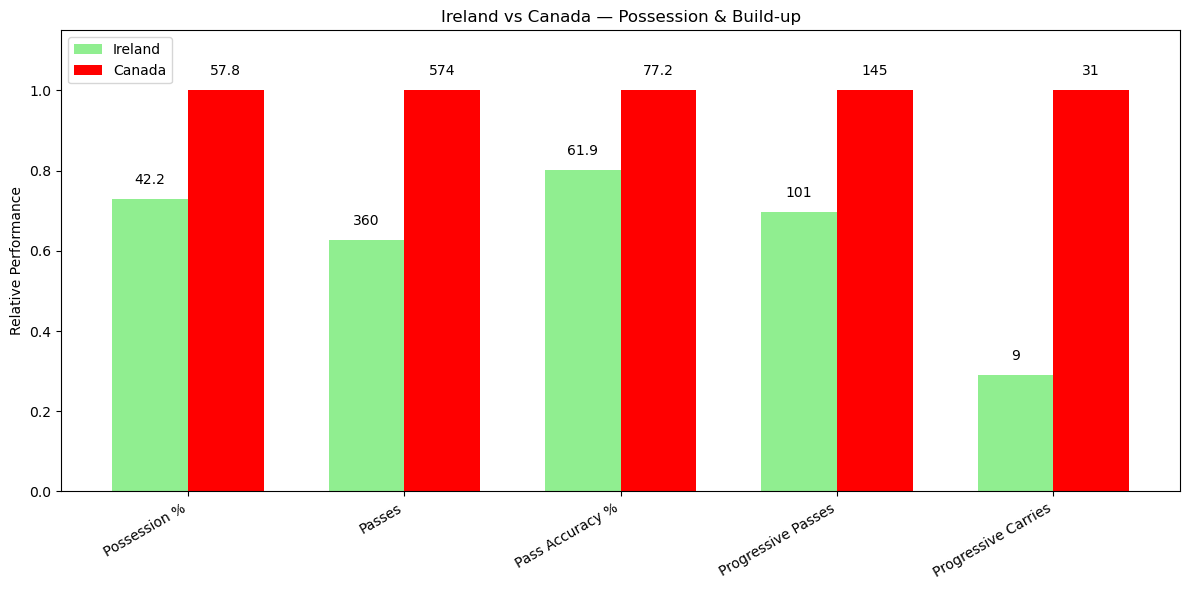

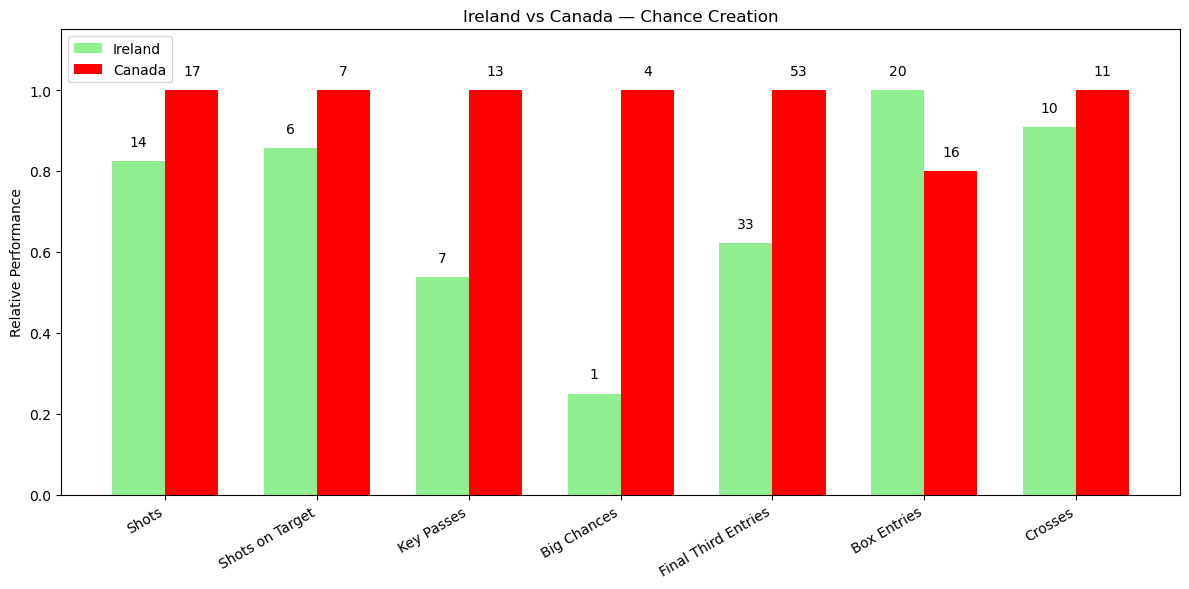

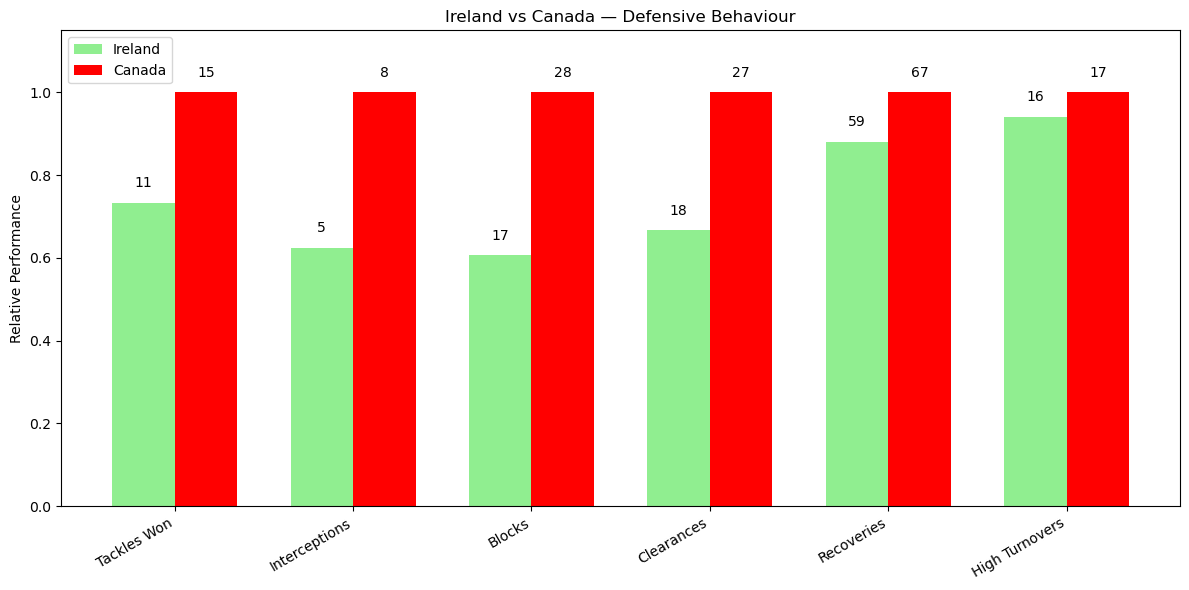

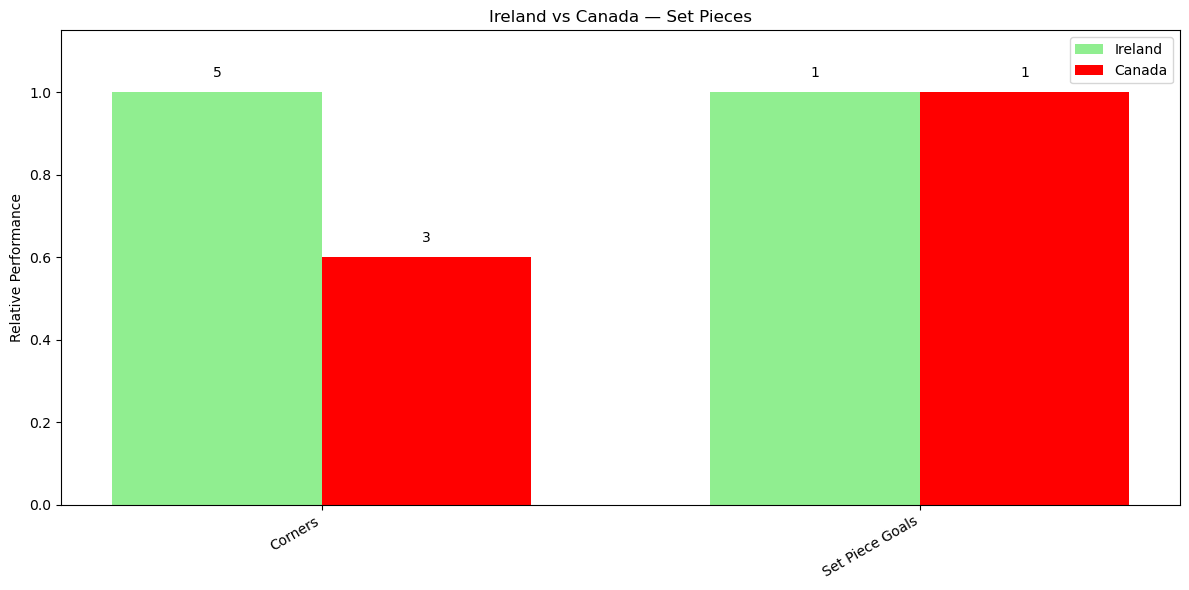

In [152]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    ( 
        (womens_world_cup_stats["team"] == "Republic of Ireland Women's") &
        (womens_world_cup_stats["opponent"] == "Canada Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Canada Women's") &
        (womens_world_cup_stats["opponent"] == "Republic of Ireland Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Ireland": "Republic of Ireland Women's",
    "Canada": "Canada Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    irl_values = np.array([
        match.loc[
            match["team"] == team_names["Ireland"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    can_values = np.array([
        match.loc[
            match["team"] == team_names["Canada"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(irl_values, can_values)

    # Normalize
    irl_normalized = np.divide(
        irl_values,
        max_values,
        out=np.zeros_like(irl_values),
        where=max_values != 0
    )

    can_normalized = np.divide(
        can_values,
        max_values,
        out=np.zeros_like(can_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_irl = plt.bar(
        x - width / 2,
        irl_normalized,
        width,
        label="Ireland",
        color="lightgreen"
    )

    bars_can = plt.bar(
        x + width / 2,
        can_normalized,
        width,
        label="Canada",
        color="red"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_irl, irl_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_can, can_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Ireland vs Canada — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion CAN-IRL

Canada dominated the game in possession, passing and progression, while also creating more attacking opportunities. With 2 goals from 1.8 xG, Canada slightly exceeded the quality of chances created, showing good finishing efficiency. Ireland also outperformed its 0.5 xG, scoring once despite creating fewer chances.

Overall, Canada had greater control and attacking volume, while both teams were relatively efficient in front of goal, with the final 2–1 scoreline reflecting Canada’s overall superiority.

# Analysis Ireland's Group Stage games

In [161]:
team = "Republic of Ireland Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
2,3893788,Australia Women's,Republic of Ireland Women's,Group
3,3893788,Republic of Ireland Women's,Australia Women's,Group
40,3893807,Canada Women's,Republic of Ireland Women's,Group
41,3893807,Republic of Ireland Women's,Canada Women's,Group
74,3893824,Nigeria Women's,Republic of Ireland Women's,Group
75,3893824,Republic of Ireland Women's,Nigeria Women's,Group


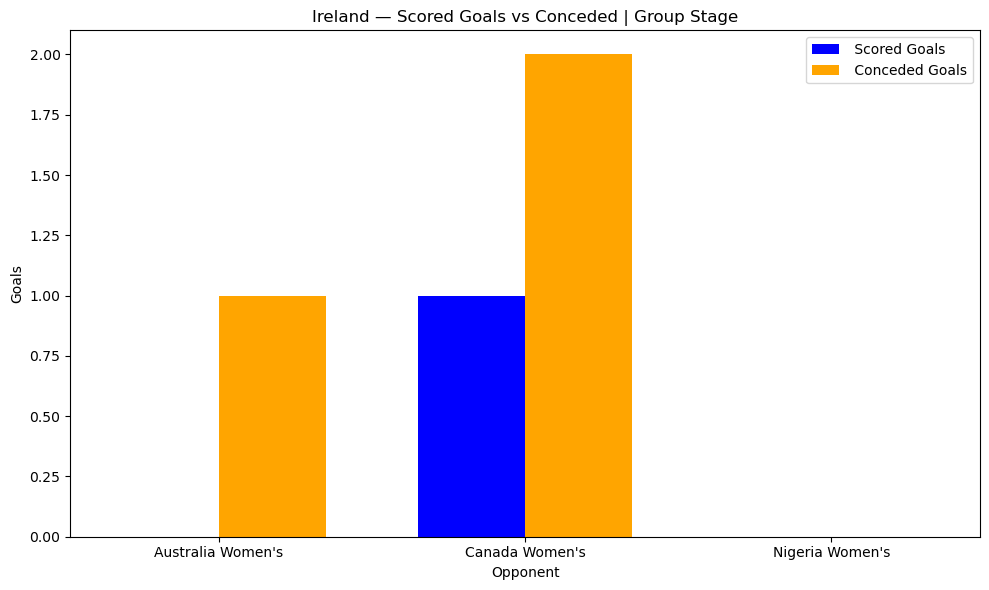

In [163]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Republic of Ireland Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Ireland — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Ireland lost two games, scored in one — with Canada — and tied one game.

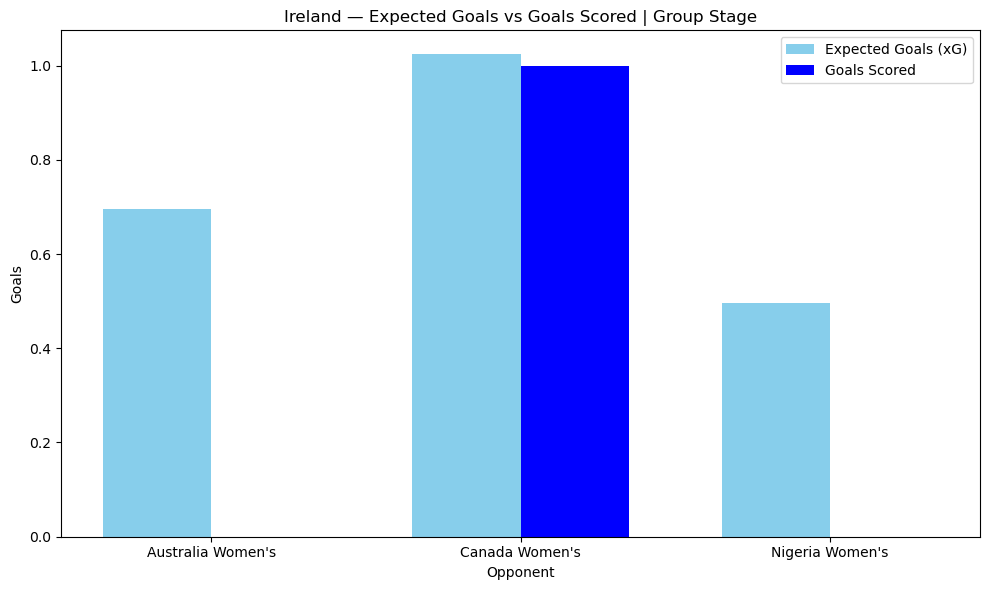

In [166]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Republic of Ireland Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Ireland — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

According to the chart above, Ireland was always below the expectations of the games.

# Final Conclusion

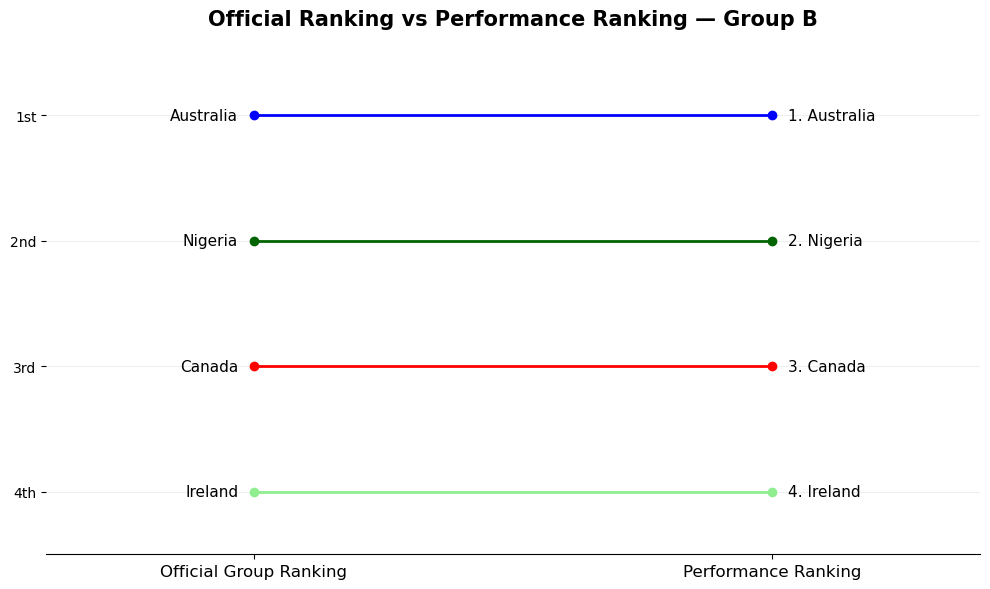

In [173]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DATA
# ==========================================

ranking = pd.DataFrame({
    "team": ["Australia", "Nigeria", "Canada", "Ireland"],
    "official_rank": [1, 2, 3, 4],
    "performance_rank": [1, 2, 3, 4]
})

# ==========================================
# COLORS
# ==========================================

team_colors = {
    "Australia": "blue",
    "Nigeria": "darkgreen",
    "Canada": "red",
    "Ireland": "lightgreen"
}

# ==========================================
# PLOT
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in ranking.iterrows():

    ax.plot(
        [0, 1],
        [row["official_rank"], row["performance_rank"]],
        marker="o",
        linewidth=2,
        color=team_colors[row["team"]]
    )

    # Official ranking
    ax.text(
        -0.03,
        row["official_rank"],
        row["team"],
        ha="right",
        va="center",
        fontsize=11
    )

    # Performance ranking
    ax.text(
        1.03,
        row["performance_rank"],
        f'{row["performance_rank"]}. {row["team"]}',
        ha="left",
        va="center",
        fontsize=11
    )

# ==========================================
# FORMATTING
# ==========================================

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(4.5, 0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Official Group Ranking",
    "Performance Ranking"
], fontsize=12)

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1st", "2nd", "3rd", "4th"])

ax.set_title(
    "Official Ranking vs Performance Ranking — Group B",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

The performance analysis closely matched the official group ranking, with Australia, Nigeria, Canada and Ireland finishing in the same order. Australia showed the strongest overall performance, while Nigeria also demonstrated enough quality and consistency to secure second place. Canada had strong possession and build-up numbers but was less effective in turning them into results, while Ireland ranked fourth across both measures.

Overall, the performance data supports the final competition outcome, suggesting that the group ranking was a fair reflection of what the teams showed on the pitch.